# Iris Flower Classification

Classify iris flowers into their three species from four measurements: sepal length, sepal width, petal length, and petal width.

In [2]:
import pandas as pd 
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Load the dataset

In [3]:
iris = load_iris()

In [4]:
dir(iris) # check contents of data set

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [5]:
X = pd.DataFrame(iris.data, columns = iris.feature_names) 

In [6]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
y = pd.DataFrame(iris.target, columns=['species'])

In [8]:
y.head()

,species
0,0
1,0
2,0
3,0
4,0


In [9]:
y.species.unique()

array([0, 1, 2])

In [10]:
y.species.replace({
    0:'setosa', 
    1:'versicolor', 
    2:'virginica', 
    },
    inplace = True, # makes changes permanent
)

In [11]:
y.species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

## Combine features and labels

Join `X` and `y` into a single DataFrame.

In [12]:
df = pd.concat([X, y], axis = 1) # Combining X and y datasets

In [13]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Explore the data

Look at distribution of measurements and confirm there are no missing values.

<Axes: xlabel='sepal length (cm)', ylabel='Density'>

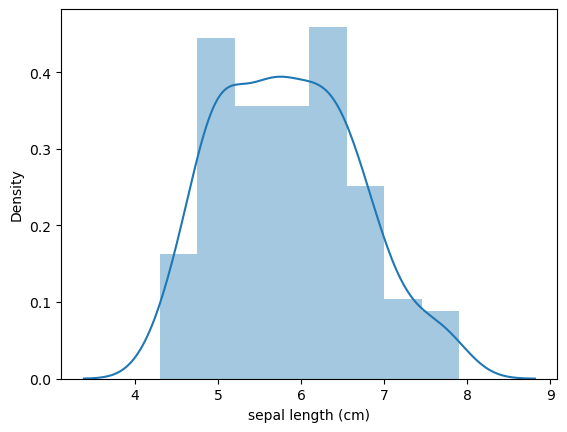

In [14]:
sns.distplot(df['sepal length (cm)']) # Distribution plot with KDE line

<Axes: xlabel='petal width (cm)', ylabel='Density'>

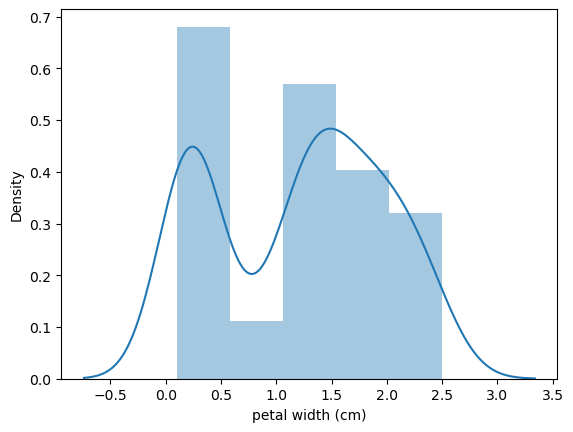

In [15]:
sns.distplot(df['petal width (cm)'])

<Axes: ylabel='species'>

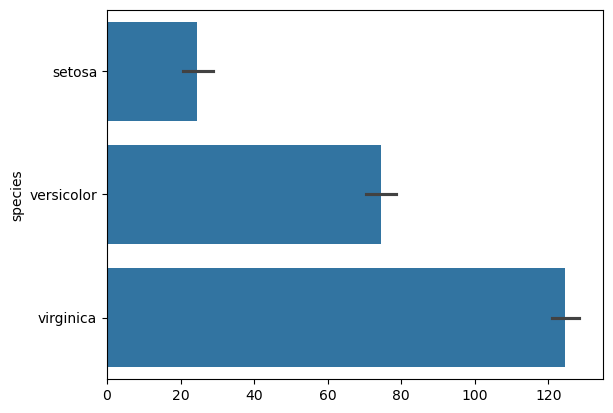

In [16]:
sns.barplot(df['species']) # Displays how many of each flower

In [17]:
df.isna().sum() # Check if the dataset consists of any null values

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

## Scale the features

Rescale every feature to the 0–1 range with `MinMaxScaler` so no single measurement skews just because of its units.

In [18]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [19]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X[:] = scaler.fit_transform(X) # [:] Stores values as Data Frame rather than array

In [20]:
X.head() # Dataset is scaled from 0-1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


## Reduce dimensions with PCA

Principal Component Analysis (PCA) combines the four correlated measurements into a smaller set of uncorrelated components

In [23]:
from sklearn.decomposition import PCA

"""
pca = PCA(n_components = 2) # This will extract 2 important columns from data set
pca = PCA(0.95) # This will extract 95% of the important data from the data set
"""

pca = PCA (0.95)
Xpca = pca.fit_transform(X)

In [26]:
X = pd.DataFrame(Xpca, columns = ['PC1', 'PC2']) # Convert Xpca to Data Frame

In [ ]:
X.head() # Shows only 2 columns because it holds most important values combined and stored into them

,PC1,PC2
0,-0.630703,0.107578
1,-0.622905,-0.104260
2,-0.669520,-0.051417
3,-0.654153,-0.102885
4,-0.648788,0.133488


## Split into training and test sets

Hold out 20% of the data to evaluate the final model on examples it never saw during training. `random_state` fixes the split so results are reproducible.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42) # Splits data into training and testing

"""
test_size=0.2 # Uses 20% of the data for testing and 80% for training
random_state=42	# Uses a fixed random seed so you get the same split every time you run the code
"""

In [31]:
X_train.shape, X_test.shape

((120, 2), (30, 2))

## Compare models with cross-validation

Compare three classifiers: Logistic Regression, Random Forest, and SVC, on the training data. `kfold` helper returns the mean accuracy as a percentage.

In [77]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [45]:
def kfold(estimator, input, target): # The model we are using, the input data (train/test), and the data we are classifying it to (train/test)
    return cross_val_score(estimator, input, target).mean() * 100 # Returns mean percent of all model testing

In [47]:
kfold(LogisticRegression(), X_train, y_train)

86.66666666666669

In [55]:
kfold(RandomForestClassifier(), X_train, y_train)

95.0

## Tune the SVC hyperparameters

`GridSearchCV` tries several values of `C` and reports which performs best under cross-validation.

In [56]:
# Evaluate best hyper parameters from data to run on SVC model

from sklearn.model_selection import GridSearchCV

clf = GridSearchCV(SVC(), {
    'C' : [0.5, 1, 2, 3]
})

clf.fit(X_train, y_train)

GridSearchCV(estimator=SVC(), param_grid={'C': [0.5, 1, 2, 3]})

In [59]:
clf_df = pd.DataFrame(clf.cv_results_)

In [60]:
clf_df.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_C', 'params', 'split0_test_score', 'split1_test_score',
       'split2_test_score', 'split3_test_score', 'split4_test_score',
       'mean_test_score', 'std_test_score', 'rank_test_score'],
      dtype='object')

In [ ]:
clf_df[['param_C', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False) # Gives us best value on the top

,param_C,mean_test_score
0,0.5,0.958333
1,1.0,0.958333
2,2.0,0.958333
3,3.0,0.958333


Train an SVC with the chosen `C` on the full training set, then measure accuracy on the held-out test set. The classification report and confusion matrix show how well each species is predicted.

In [66]:
model = SVC(C = 0.5)
model.fit(X_train, y_train)

SVC(C=0.5)

In [67]:
model.score(X_test, y_test) * 100

96.66666666666667

In [68]:
pred = model.predict(X_test)

In [71]:
y_test[:5]

,species
73,versicolor
18,setosa
118,virginica
78,versicolor
76,versicolor


In [73]:
pred[:5]

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor'],
      dtype=object)

In [74]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



Text(50.722222222222214, 0.5, 'Actual')

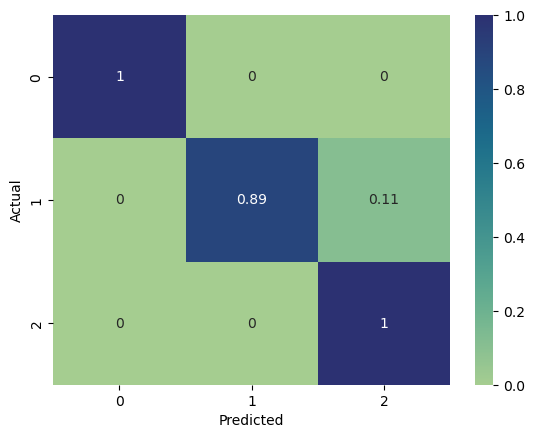

In [76]:
cf = confusion_matrix(y_test, pred, normalize='true')
sns.heatmap(cf, annot = True, cmap = 'crest')
plt.xlabel('Predicted')
plt.ylabel('Actual')